# 🔍 Bottleneck Prediction Model

This notebook builds a **binary classification model** that labels system states as either **"Bottleneck"** or **"Working"** based on system performance metrics.

### Pipeline Overview
1. **Stage 1** — Data Loading & Exploratory Data Analysis (EDA)
2. **Stage 2** — Data Preprocessing (Scaling, Train/Test Split)
3. **Stage 3** — Handling Class Imbalance (SMOTE)
4. **Stage 4** — Model Training & Comparison
5. **Stage 5** — Model Evaluation (Metrics, Confusion Matrix, ROC Curves)
6. **Stage 6** — Bottleneck Point Prediction & Visualization

### Dataset
- **Source**: `Datasets/Big_data_dataset.csv`
- **Target**: `status` column (0 = Working, 1 = Bottleneck)
- **Challenge**: Extreme class imbalance (99% Working vs 1% Bottleneck)

---
## Stage 0 — Import Libraries

We import all the necessary libraries upfront:
- **pandas / numpy** for data manipulation
- **matplotlib / seaborn** for visualization
- **scikit-learn** for preprocessing, model training, and evaluation
- **XGBoost** for gradient-boosted tree classifier
- **imbalanced-learn (SMOTE)** for handling class imbalance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    f1_score, precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# Create results directory for saving plots
os.makedirs('results', exist_ok=True)

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Stage 1 — Data Loading & Exploratory Data Analysis (EDA)

In this stage we:
1. **Load** the CSV dataset
2. **Inspect** its shape, data types, and summary statistics
3. **Visualize** the class distribution to confirm the imbalance
4. **Plot** a correlation heatmap to understand feature relationships
5. **Generate** feature distribution histograms for both classes

In [2]:
# ─── 1.1 Load the dataset ─────────────────────────────────────────────
df = pd.read_csv('Datasets/Big_data_dataset.csv')

print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print()
df.head()

Dataset shape: (10000, 12)
Columns: ['cpu_utilization', 'memory_usage', 'disk_io', 'network_latency', 'process_count', 'thread_count', 'context_switches', 'cache_miss_rate', 'temperature', 'power_consumption', 'uptime', 'status']



,cpu_utilization,memory_usage,disk_io,network_latency,process_count,thread_count,context_switches,cache_miss_rate,temperature,power_consumption,uptime,status
0,40.581311,43.627674,36.769917,127.990769,646,3230,1500,0.065837,82.782403,255.012964,715.803096,0
1,95.317859,39.962089,10.041088,92.399198,626,3130,243,0.123481,59.424540,81.204822,86.158314,0
2,74.539424,25.853852,17.985345,192.935206,101,303,229,0.025459,90.973363,210.685067,545.755982,0
3,61.872556,64.654000,33.500751,44.576712,52,156,1574,0.178884,37.344280,90.398182,541.918137,0
4,19.821771,52.896174,24.622378,117.983427,126,378,1164,0.167508,40.203942,87.099085,113.660688,0


In [3]:
# ─── 1.2 Basic statistics & info ──────────────────────────────────────
print('=== Data Types ===')
print(df.dtypes)
print()
print('=== Missing Values ===')
print(df.isnull().sum())
print()
print('=== Summary Statistics ===')
df.describe()

=== Data Types ===
cpu_utilization      float64
memory_usage         float64
disk_io              float64
network_latency      float64
process_count          int64
thread_count           int64
context_switches       int64
cache_miss_rate      float64
temperature          float64
power_consumption    float64
uptime               float64
status                 int64
dtype: object

=== Missing Values ===
cpu_utilization      0
memory_usage         0
disk_io              0
network_latency      0
process_count        0
thread_count         0
context_switches     0
cache_miss_rate      0
temperature          0
power_consumption    0
uptime               0
status               0
dtype: int64

=== Summary Statistics ===


,cpu_utilization,memory_usage,disk_io,network_latency,process_count,thread_count,context_switches,cache_miss_rate,temperature,power_consumption,uptime,status
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,51.945158,55.407689,25.502469,100.243963,517.236300,1811.330800,1038.862700,0.105904,62.376722,174.786780,500.381365,0.009700
std,27.324862,26.036510,14.051914,57.509924,275.023237,1167.260691,549.991836,0.055232,18.876303,71.993941,286.607554,0.098015
min,5.001105,10.014197,1.002358,1.001102,50.000000,100.000000,100.000000,0.010009,30.007482,50.043787,1.330765,0.000000
25%,28.401243,32.855122,13.433648,50.124593,277.000000,862.000000,559.000000,0.058344,45.980633,113.033926,251.078668,0.000000
50%,51.790219,55.530710,25.601337,100.506018,512.000000,1598.000000,1037.000000,0.105203,62.192959,173.836965,503.659313,0.000000
75%,75.300603,78.083130,37.489019,149.676135,755.000000,2598.500000,1508.000000,0.154801,78.975899,236.487255,746.406942,0.000000
max,99.973179,99.993234,49.995148,199.958085,999.000000,4995.000000,1999.000000,0.199980,94.993040,299.966517,999.912068,1.000000


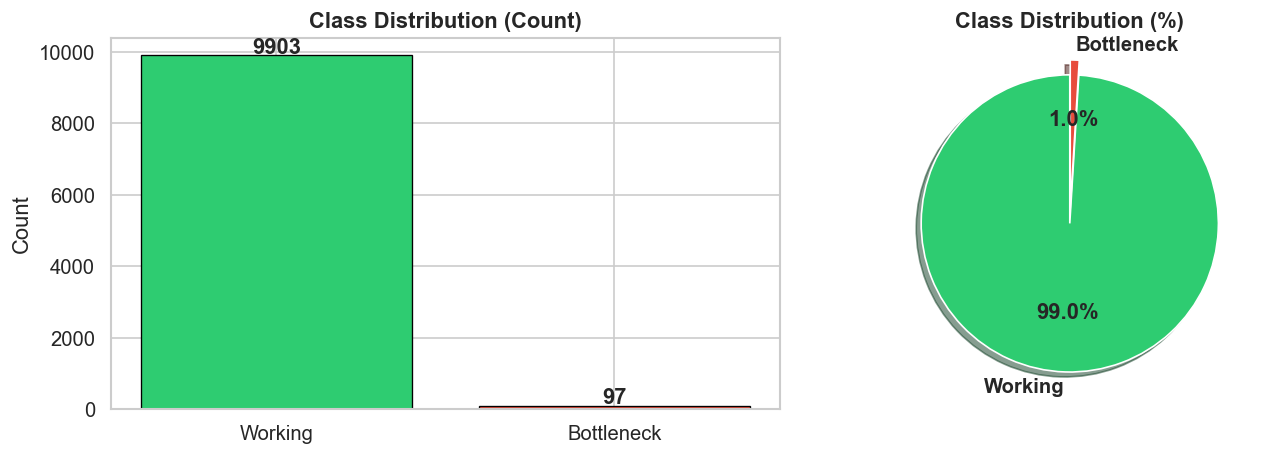


Working:    9,903 samples (99.0%)
Bottleneck: 97 samples (1.0%)
Imbalance ratio: 102:1


In [4]:
# ─── 1.3 Class distribution ──────────────────────────────────────────
status_counts = df['status'].value_counts()
labels_map = {0: 'Working', 1: 'Bottleneck'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar([labels_map[i] for i in status_counts.index], status_counts.values, color=colors, edgecolor='black', linewidth=0.8)
for bar, count in zip(bars, status_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, str(count), ha='center', fontweight='bold')
axes[0].set_title('Class Distribution (Count)', fontweight='bold')
axes[0].set_ylabel('Count')




# Pie chart
axes[1].pie(status_counts.values, labels=[labels_map[i] for i in status_counts.index],
            autopct='%1.1f%%', colors=colors, startangle=90, explode=(0, 0.1),
            shadow=True, textprops={'fontweight': 'bold'})
axes[1].set_title('Class Distribution (%)', fontweight='bold')

plt.tight_layout()
plt.savefig('results/01_class_distribution.png', bbox_inches='tight')
plt.show()

print(f'\nWorking:    {status_counts[0]:,} samples ({status_counts[0]/len(df)*100:.1f}%)')
print(f'Bottleneck: {status_counts[1]:,} samples ({status_counts[1]/len(df)*100:.1f}%)')
print(f'Imbalance ratio: {status_counts[0]//status_counts[1]}:1')

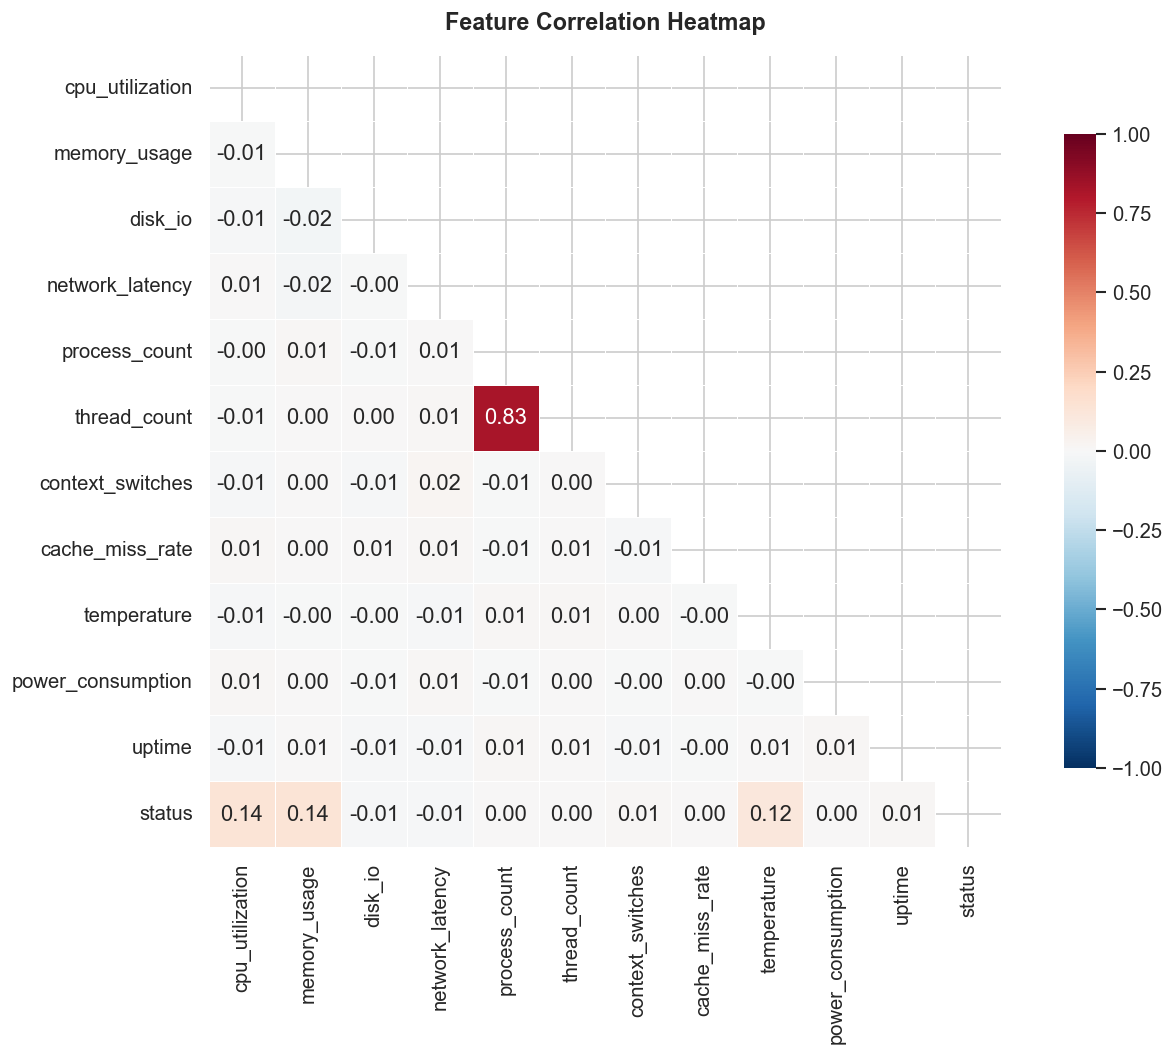

In [5]:
# ─── 1.4 Correlation heatmap ─────────────────────────────────────────
plt.figure(figsize=(12, 9))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('results/02_correlation_heatmap.png', bbox_inches='tight')
plt.show()

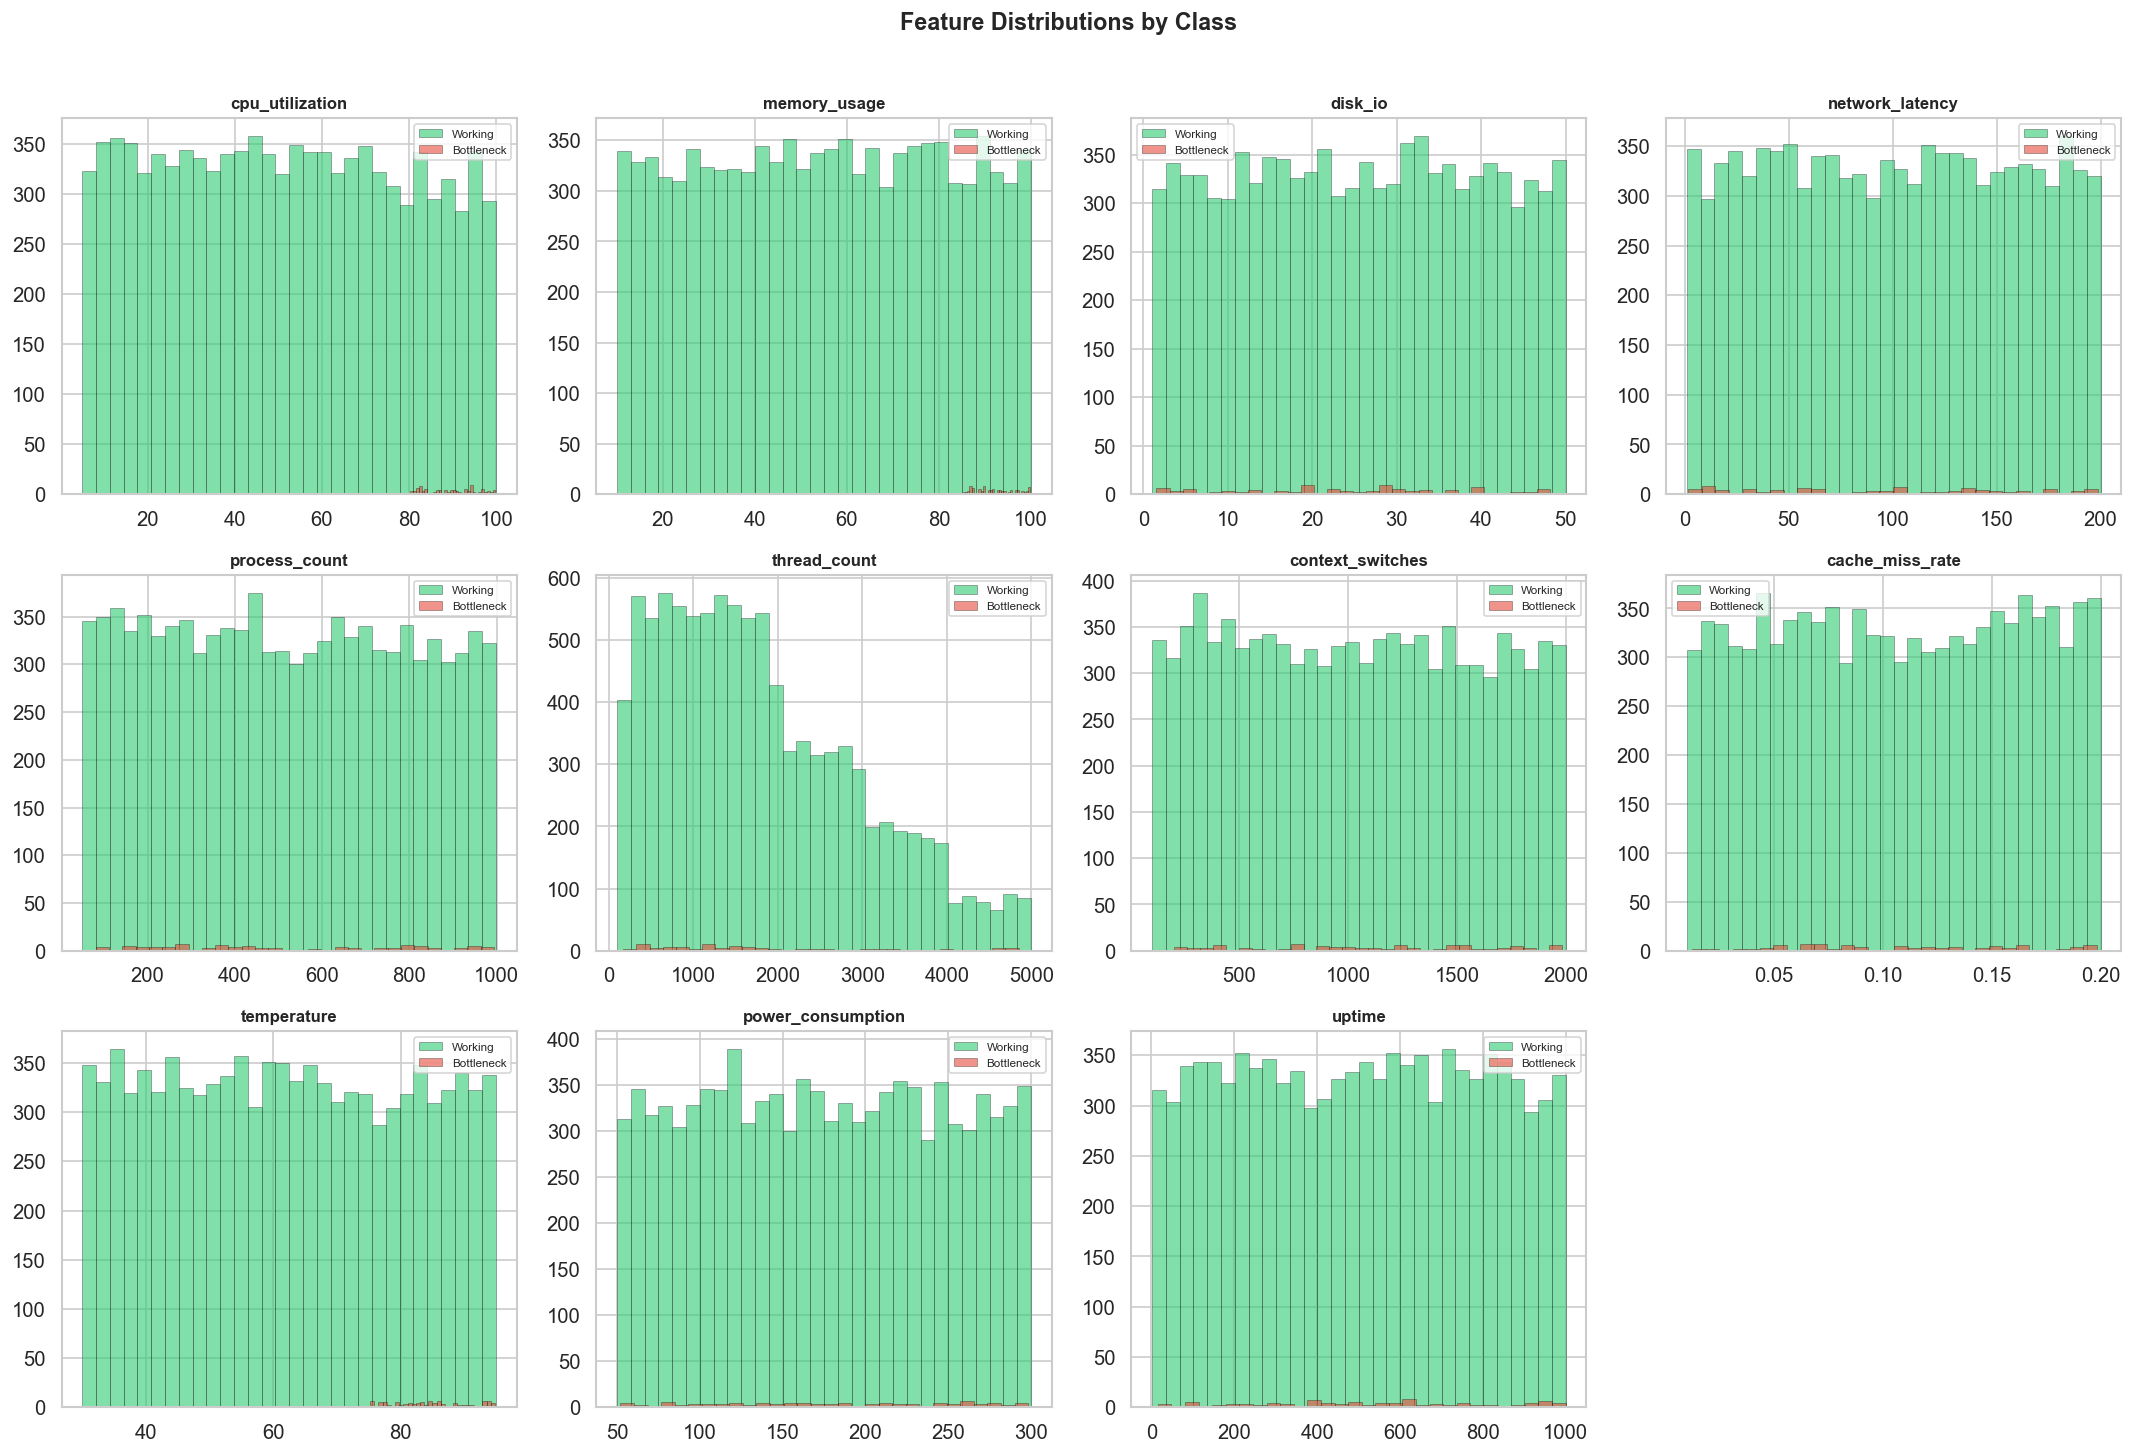

In [6]:
# ─── 1.5 Feature distributions by class ──────────────────────────────
features = [col for col in df.columns if col != 'status']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    for status_val, color, label in [(0, '#2ecc71', 'Working'), (1, '#e74c3c', 'Bottleneck')]:
        subset = df[df['status'] == status_val][feat]
        ax.hist(subset, bins=30, alpha=0.6, color=color, label=label, edgecolor='black', linewidth=0.3)
    ax.set_title(feat, fontweight='bold', fontsize=10)
    ax.legend(fontsize=7)

# Hide the unused 12th subplot
axes[-1].set_visible(False)

plt.suptitle('Feature Distributions by Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results/03_feature_distributions.png', bbox_inches='tight')
plt.show()

---
## Stage 2 — Data Preprocessing

In this stage we prepare the data for model training:
1. **Separate** features (X) from target (y)
2. **Split** into training (80%) and testing (20%) sets using stratified sampling to preserve class ratio
3. **Standardize** features using `StandardScaler` — fitted on training data only, then applied to both sets to prevent data leakage

In [7]:
# ─── 2.1 Separate features and target ────────────────────────────────
X = df.drop('status', axis=1)
y = df['status']

print(f'Features shape: {X.shape}')
print(f'Target shape:   {y.shape}')
print(f'Feature names:  {list(X.columns)}')

Features shape: (10000, 11)
Target shape:   (10000,)
Feature names:  ['cpu_utilization', 'memory_usage', 'disk_io', 'network_latency', 'process_count', 'thread_count', 'context_switches', 'cache_miss_rate', 'temperature', 'power_consumption', 'uptime']


T-Test

In [8]:
from scipy import stats
import pandas as pd

# This function runs a T-test on every feature to see if the difference
# between Working (0) and Bottleneck (1) is statistically significant.
def run_hypothesis_tests(data, target_col='status'):
    working_group = data[data[target_col] == 0]
    bottleneck_group = data[data[target_col] == 1]
    
    results = []
    # Test all columns except the target
    features_to_test = [col for col in data.columns if col != target_col]
    
    for feature in features_to_test:
        # equal_var=False runs Welch's T-test
        t_stat, p_value = stats.ttest_ind(
            working_group[feature], 
            bottleneck_group[feature], 
            equal_var=False, 
            nan_policy='omit'
        )
        
        results.append({
            'Feature': feature,
            'T-Statistic': round(t_stat, 4),
            'P-Value': p_value,
            'Statistically Significant (p < 0.05)': p_value < 0.05
        })
        
    # Return as a clean DataFrame sorted by lowest P-Value (most significant)
    return pd.DataFrame(results).sort_values(by='P-Value')

# Execute and display
hypothesis_results = run_hypothesis_tests(df)
print("\n--- Feature Significance (Two-Sample T-Test) ---")
display(hypothesis_results)


--- Feature Significance (Two-Sample T-Test) ---


,Feature,T-Statistic,P-Value,Statistically Significant (p < 0.05)
1,memory_usage,-72.1953,1.247989e-130,True
0,cpu_utilization,-57.8773,7.225509e-100,True
8,temperature,-36.3650,1.525941e-65,True
6,context_switches,-1.5532,1.235902e-01,False
2,disk_io,1.0640,2.899585e-01,False
10,uptime,-1.0587,2.923184e-01,False
3,network_latency,0.8992,3.707720e-01,False
9,power_consumption,-0.3676,7.139984e-01,False
7,cache_miss_rate,-0.3654,7.156031e-01,False
5,thread_count,-0.1207,9.041466e-01,False


In [9]:
# ─── 2.2 Train/test split (stratified) ───────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'  Working:    {(y_train == 0).sum()}')
print(f'  Bottleneck: {(y_train == 1).sum()}')
print()
print(f'Testing set:  {X_test.shape[0]} samples')
print(f'  Working:    {(y_test == 0).sum()}')
print(f'  Bottleneck: {(y_test == 1).sum()}')

Training set: 8000 samples
  Working:    7922
  Bottleneck: 78

Testing set:  2000 samples
  Working:    1981
  Bottleneck: 19


In [10]:
# ─── 2.3 Feature scaling ─────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Keep as DataFrames for easier inspection
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print('Scaling complete. Sample of scaled training data:')
X_train_scaled.head()

Scaling complete. Sample of scaled training data:


,cpu_utilization,memory_usage,disk_io,network_latency,process_count,thread_count,context_switches,cache_miss_rate,temperature,power_consumption,uptime
4715,-0.595091,-1.284473,-1.692180,-0.825631,0.610671,0.209708,-1.692014,0.443287,1.345115,-0.400291,0.710528
5398,-0.339268,0.082543,1.568876,-0.281365,0.879481,-0.248633,1.061728,0.117696,-1.405507,-0.963334,-1.474633
974,-1.601605,0.811275,-0.726183,0.620481,0.541653,-0.407389,-1.664695,1.421138,-0.104885,-1.606575,1.664815
7664,-0.467713,0.500049,-0.924532,1.704394,-1.467151,-1.351385,-1.373294,1.171061,1.123569,-1.307512,-1.693888
2266,0.345999,-1.612771,0.519724,1.149530,-1.056672,-1.158488,-1.489854,-0.024868,1.008163,-0.305941,-0.558851


---
## Stage 3 — Handling Class Imbalance with SMOTE

The dataset is **extremely imbalanced** (99:1 ratio). Training directly on this data would bias models toward the majority class ("Working").

**SMOTE** (Synthetic Minority Over-sampling Technique) creates synthetic samples of the minority class by interpolating between existing minority samples. Key points:
- SMOTE is applied **only to the training set** — the test set remains untouched to ensure unbiased evaluation
- After SMOTE, both classes have roughly equal representation in the training data

In [11]:
# ─── 3.1 Apply SMOTE ─────────────────────────────────────────────────
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print('Before SMOTE:')
print(f'  Working:    {(y_train == 0).sum()}')
print(f'  Bottleneck: {(y_train == 1).sum()}')
print()
print('After SMOTE:')
print(f'  Working:    {(y_train_resampled == 0).sum()}')
print(f'  Bottleneck: {(y_train_resampled == 1).sum()}')
print(f'\nTotal training samples: {len(y_train)} → {len(y_train_resampled)}')

Before SMOTE:
  Working:    7922
  Bottleneck: 78

After SMOTE:
  Working:    7922
  Bottleneck: 7922

Total training samples: 8000 → 15844


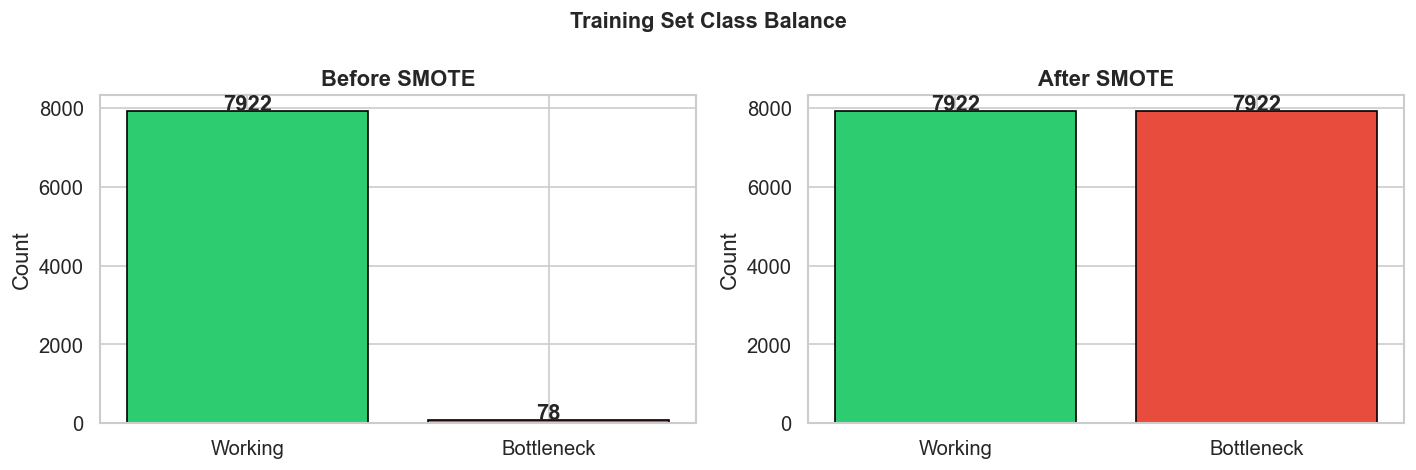

In [12]:
# ─── 3.2 Visualize the class balance before and after SMOTE ──────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#2ecc71', '#e74c3c']

# Before SMOTE
before_counts = [int((y_train == 0).sum()), int((y_train == 1).sum())]
bars1 = axes[0].bar(['Working', 'Bottleneck'], before_counts, color=colors, edgecolor='black')
for bar, count in zip(bars1, before_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(count), ha='center', fontweight='bold')
axes[0].set_title('Before SMOTE', fontweight='bold')
axes[0].set_ylabel('Count')

# After SMOTE
after_counts = [int((y_train_resampled == 0).sum()), int((y_train_resampled == 1).sum())]
bars2 = axes[1].bar(['Working', 'Bottleneck'], after_counts, color=colors, edgecolor='black')
for bar, count in zip(bars2, after_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(count), ha='center', fontweight='bold')
axes[1].set_title('After SMOTE', fontweight='bold')
axes[1].set_ylabel('Count')

plt.suptitle('Training Set Class Balance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/04_smote_balance.png', bbox_inches='tight')
plt.show()

---
## Stage 4 — Model Training & Comparison

We train **four different classifiers** and compare their performance:

| Model | Why |
|---|---|
| **Logistic Regression** | Simple linear baseline, fast training |
| **Random Forest** | Ensemble of decision trees, handles non-linearity well |
| **XGBoost** | State-of-the-art gradient boosting, often best for tabular data |
| **SVM (RBF kernel)** | Effective in high-dimensional spaces, good for binary classification |

All models also use `class_weight='balanced'` or equivalent as an additional safeguard against imbalance (on top of SMOTE).

In [13]:
# ─── 4.1 Define models ───────────────────────────────────────────────
# Calculate scale_pos_weight for XGBoost
neg_count = int((y_train_resampled == 0).sum())
pos_count = int((y_train_resampled == 1).sum())
scale_pos = neg_count / pos_count if pos_count > 0 else 1

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, scale_pos_weight=scale_pos,
        eval_metric='logloss', random_state=42, use_label_encoder=False
    ),
    'SVM (RBF)': SVC(
        kernel='rbf', class_weight='balanced', probability=True, random_state=42
    )
}

print(f'Models to train: {list(models.keys())}')

Models to train: ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM (RBF)']


In [14]:
# ─── 4.2 Train all models ────────────────────────────────────────────
trained_models = {}

for name, model in models.items():
    print(f'Training {name}...', end=' ')
    model.fit(X_train_resampled, y_train_resampled)
    trained_models[name] = model
    print('✓')

print('\nAll models trained successfully!')

Training Logistic Regression... ✓
Training Random Forest... ✓
Training XGBoost... ✓
Training SVM (RBF)... ✓

All models trained successfully!


---
## Stage 5 — Model Evaluation

We evaluate each model using metrics suitable for **imbalanced classification**:
- **Precision** — Of predicted bottlenecks, how many are actually bottlenecks?
- **Recall** — Of actual bottlenecks, how many did we catch?
- **F1-Score** — Harmonic mean of precision and recall (our primary metric)
- **Confusion Matrix** — Visual breakdown of true/false positives and negatives
- **ROC-AUC** — Overall model discrimination ability

> **Note**: We focus on the **Bottleneck class F1-score** as the key metric, since correctly identifying bottlenecks is the main goal.

In [15]:
# ─── 5.1 Classification reports ──────────────────────────────────────
results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    f1_bottleneck = f1_score(y_test, y_pred, pos_label=1)
    
    results[name] = {
        'y_pred': y_pred,
        'y_prob': y_prob,
        'f1_bottleneck': f1_bottleneck
    }
    
    print(f'\n{"="*60}')
    print(f'  {name}')
    print(f'{"="*60}')
    report = classification_report(y_test, y_pred, target_names=['Working', 'Bottleneck'])
    print(report)
    print(f'  → Bottleneck F1-Score: {f1_bottleneck:.4f}')


  Logistic Regression
              precision    recall  f1-score   support

     Working       1.00      0.97      0.99      1981
  Bottleneck       0.27      1.00      0.42        19

    accuracy                           0.97      2000
   macro avg       0.63      0.99      0.70      2000
weighted avg       0.99      0.97      0.98      2000

  → Bottleneck F1-Score: 0.4222

  Random Forest
              precision    recall  f1-score   support

     Working       1.00      1.00      1.00      1981
  Bottleneck       1.00      0.95      0.97        19

    accuracy                           1.00      2000
   macro avg       1.00      0.97      0.99      2000
weighted avg       1.00      1.00      1.00      2000

  → Bottleneck F1-Score: 0.9730

  XGBoost
              precision    recall  f1-score   support

     Working       1.00      1.00      1.00      1981
  Bottleneck       1.00      0.95      0.97        19

    accuracy                           1.00      2000
   macro avg 

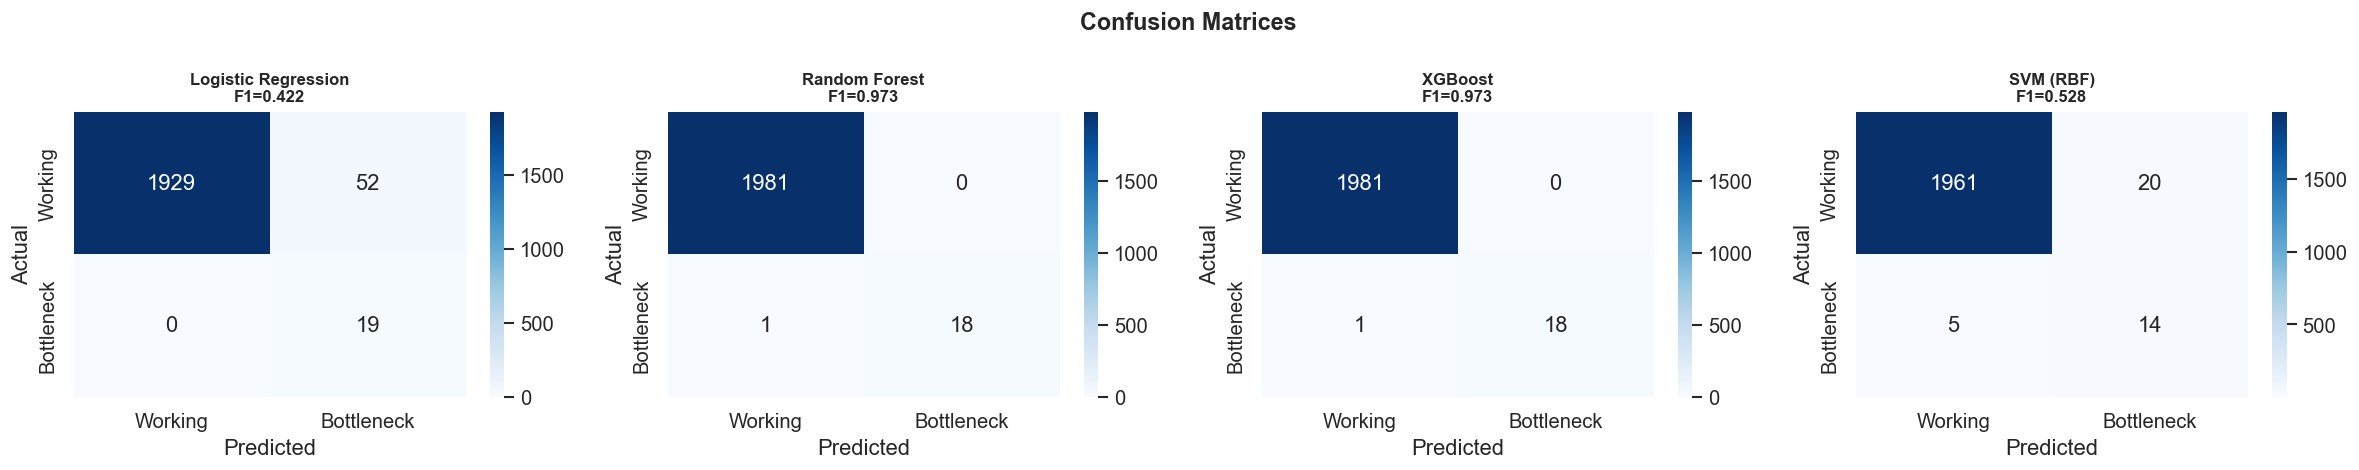

In [16]:
# ─── 5.2 Confusion matrices ──────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Working', 'Bottleneck'],
                yticklabels=['Working', 'Bottleneck'])
    ax.set_title(f'{name}\nF1={res["f1_bottleneck"]:.3f}', fontweight='bold', fontsize=10)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/05_confusion_matrices.png', bbox_inches='tight')
plt.show()

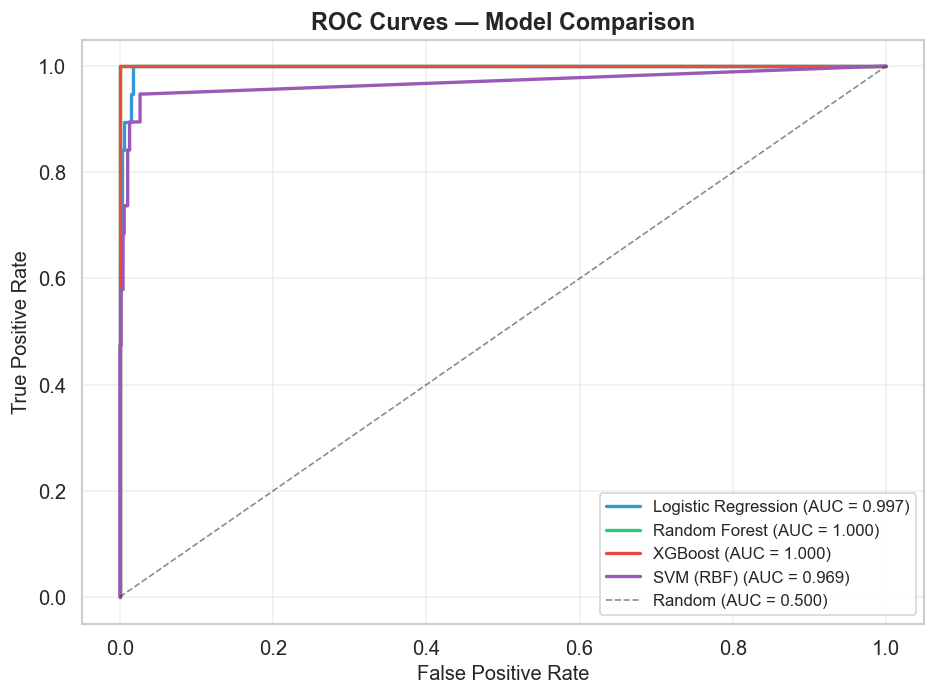

In [17]:
# ─── 5.3 ROC curves ──────────────────────────────────────────────────
plt.figure(figsize=(8, 6))
colors_roc = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC = 0.500)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/06_roc_curves.png', bbox_inches='tight')
plt.show()

In [18]:
# ─── 5.4 Select best model ───────────────────────────────────────────
best_name = max(results, key=lambda k: results[k]['f1_bottleneck'])
best_model = trained_models[best_name]

# Summary table
summary_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Bottleneck F1': [res['f1_bottleneck'] for res in results.values()],
    'AUC': [auc(*roc_curve(y_test, res['y_prob'])[:2]) for res in results.values()]
}).sort_values('Bottleneck F1', ascending=False)

print('═' * 50)
print('        MODEL COMPARISON SUMMARY')
print('═' * 50)
print(summary_df.to_string(index=False))
print(f'\n🏆 Best Model: {best_name} (F1 = {results[best_name]["f1_bottleneck"]:.4f})')

══════════════════════════════════════════════════
        MODEL COMPARISON SUMMARY
══════════════════════════════════════════════════
              Model  Bottleneck F1      AUC
      Random Forest       0.972973 1.000000
            XGBoost       0.972973 0.999973
          SVM (RBF)       0.528302 0.968849
Logistic Regression       0.422222 0.997370

🏆 Best Model: Random Forest (F1 = 0.9730)


---
## Stage 6 — Bottleneck Point Prediction & Visualization

Using the **best-performing model**, we now:
1. **Predict** on the entire dataset to identify all bottleneck points
2. **List** the predicted bottleneck data points with their feature values
3. **Visualize** bottleneck vs working points using scatter plots across key features
4. **Plot feature importance** to understand which metrics most influence bottleneck detection

In [19]:
# ─── 6.1 Predict on full dataset ─────────────────────────────────────
X_full_scaled = scaler.transform(X)
df['predicted_status'] = best_model.predict(X_full_scaled)
df['predicted_label'] = df['predicted_status'].map({0: 'Working', 1: 'Bottleneck'})
df['actual_label'] = df['status'].map({0: 'Working', 1: 'Bottleneck'})

predicted_bottlenecks = df[df['predicted_status'] == 1]
actual_bottlenecks = df[df['status'] == 1]

print(f'Actual bottleneck points:    {len(actual_bottlenecks)}')
print(f'Predicted bottleneck points: {len(predicted_bottlenecks)}')
print(f'\nUsing model: {best_name}')

Actual bottleneck points:    97
Predicted bottleneck points: 96

Using model: Random Forest


In [20]:
# ─── 6.2 Display predicted bottleneck points ─────────────────────────
print(f'\n{"="*60}')
print(f'  PREDICTED BOTTLENECK POINTS ({len(predicted_bottlenecks)} found)')
print(f'{"="*60}\n')

display_cols = features + ['actual_label', 'predicted_label']
predicted_bottlenecks[display_cols]


  PREDICTED BOTTLENECK POINTS (96 found)



,cpu_utilization,memory_usage,disk_io,network_latency,process_count,thread_count,context_switches,cache_miss_rate,temperature,power_consumption,uptime,actual_label,predicted_label
52,94.252399,91.339054,29.051188,115.589702,152,304,885,0.146586,93.861883,161.552912,637.246759,Bottleneck,Bottleneck
127,86.769405,86.210472,4.462281,62.565100,964,1928,1269,0.107579,77.184943,134.520655,437.436595,Bottleneck,Bottleneck
150,91.285259,89.982389,4.816795,59.371372,332,664,332,0.111905,88.161094,186.500455,277.004361,Bottleneck,Bottleneck
186,82.636109,86.421902,10.492711,12.901887,641,1282,1746,0.099922,79.543407,214.549698,936.760702,Bottleneck,Bottleneck
245,93.190263,97.028652,12.890896,176.463323,726,1452,595,0.038249,84.419435,243.237746,52.986555,Bottleneck,Bottleneck
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9746,80.283384,90.879075,20.055435,175.061102,507,1521,984,0.153902,81.997265,260.564386,739.094689,Bottleneck,Bottleneck
9863,81.571568,99.510901,12.402555,36.905776,807,1614,1956,0.092841,94.802712,115.327426,90.930042,Bottleneck,Bottleneck
9886,89.671853,98.422196,9.365620,63.361571,575,1150,262,0.080663,93.007004,186.029831,808.698585,Bottleneck,Bottleneck
9928,84.346783,91.794449,22.423786,90.583166,273,819,1225,0.081745,76.518033,218.842472,621.240535,Bottleneck,Bottleneck


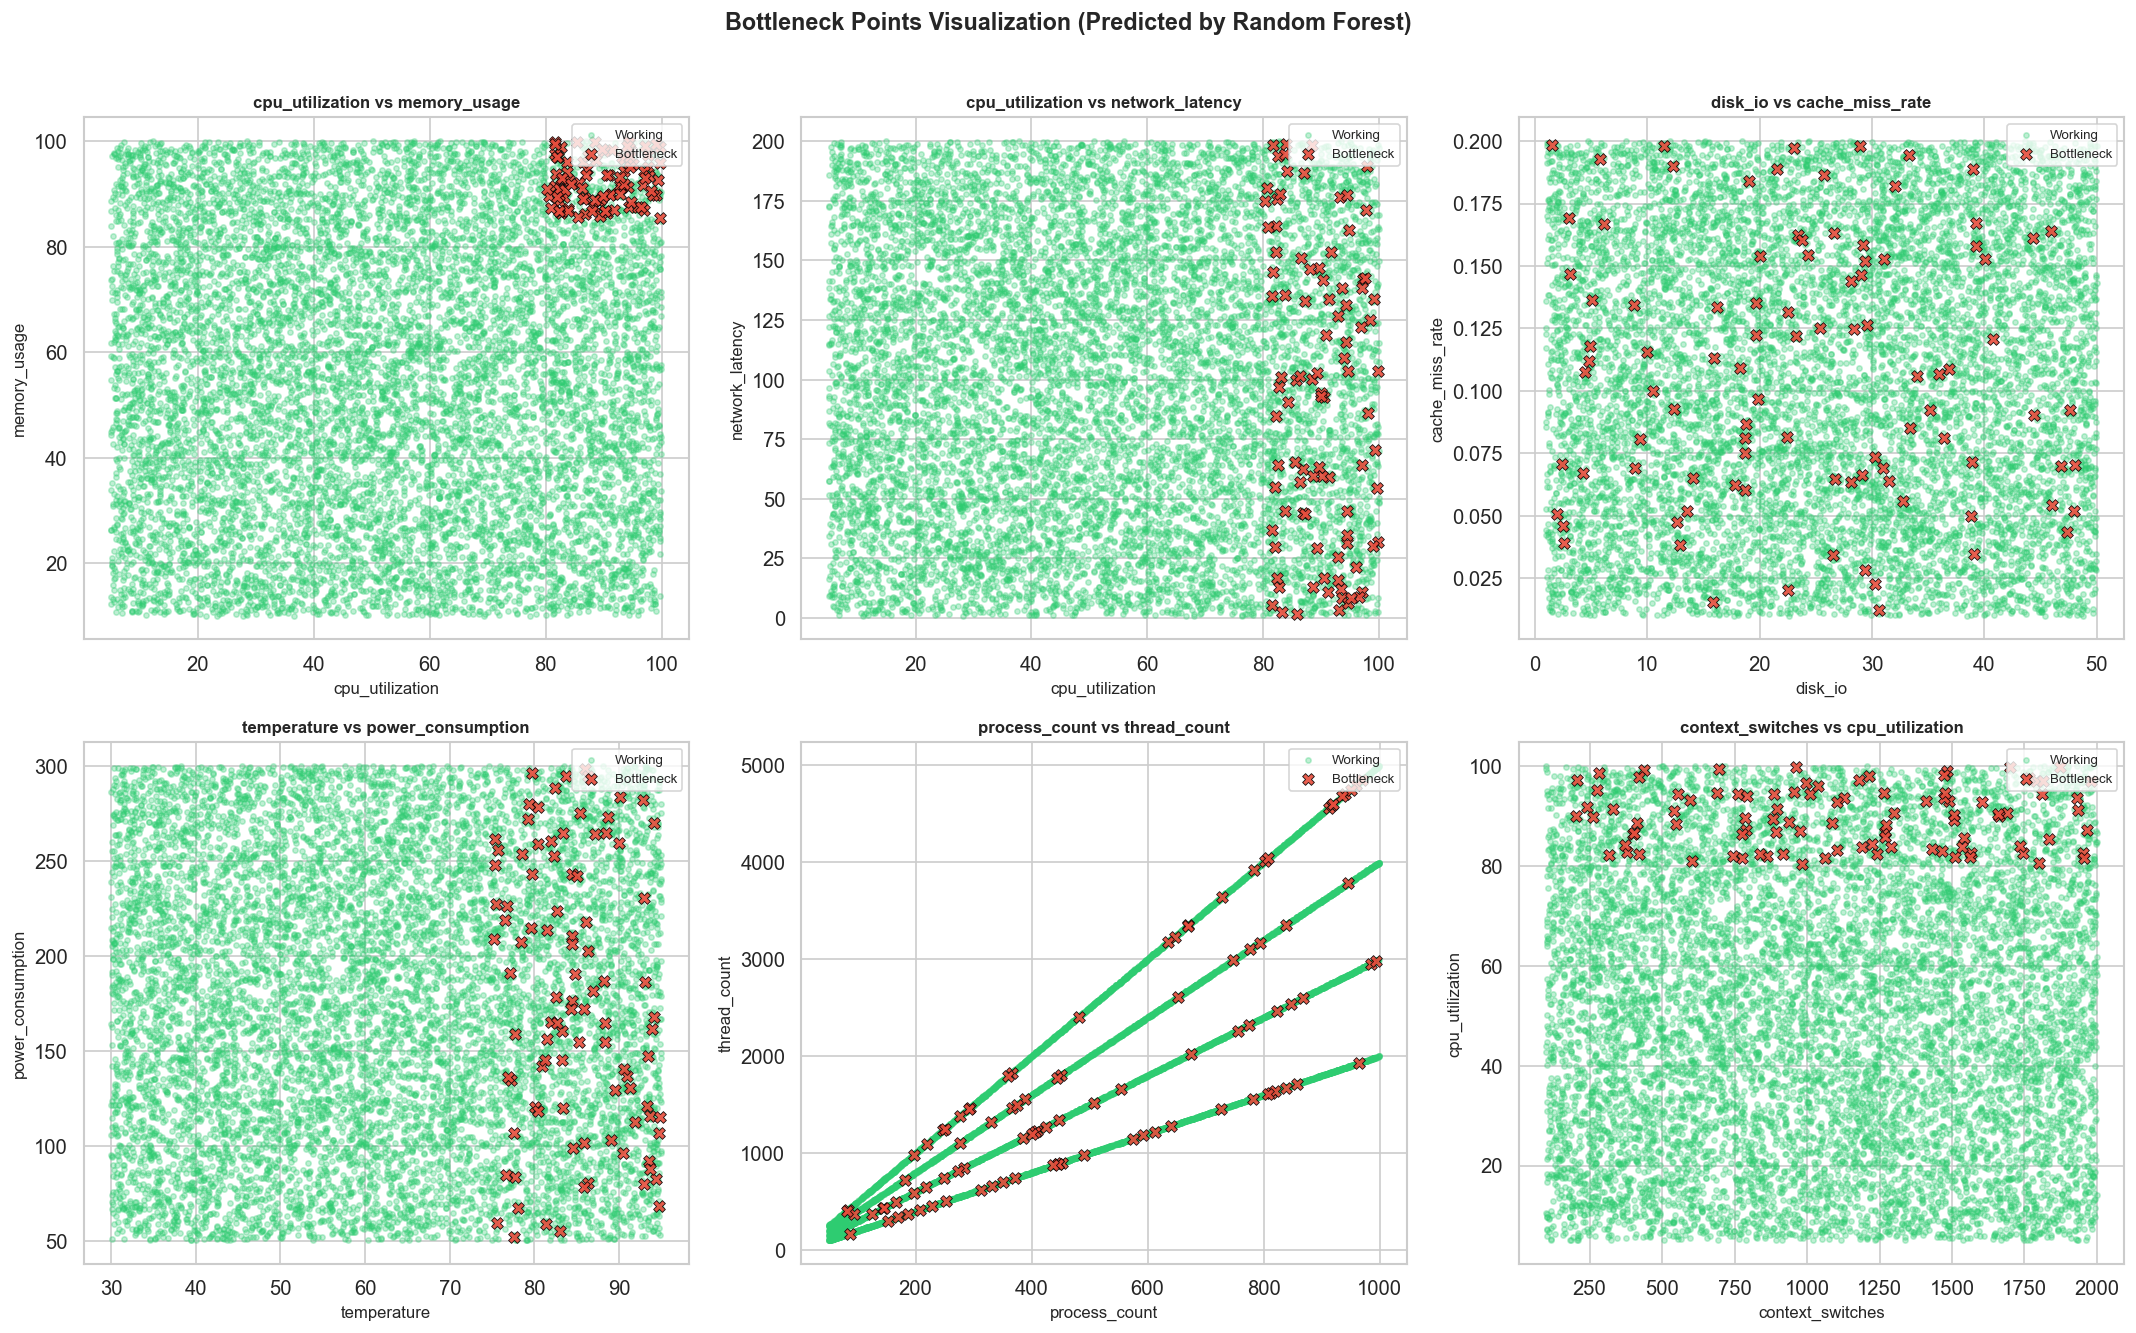

In [21]:
# ─── 6.3 Scatter plots — Bottleneck vs Working (by prediction) ──────
# Select most informative feature pairs for scatter plots
scatter_pairs = [
    ('cpu_utilization', 'memory_usage'),
    ('cpu_utilization', 'network_latency'),
    ('disk_io', 'cache_miss_rate'),
    ('temperature', 'power_consumption'),
    ('process_count', 'thread_count'),
    ('context_switches', 'cpu_utilization')
]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for ax, (feat_x, feat_y) in zip(axes, scatter_pairs):
    working = df[df['predicted_status'] == 0]
    bottleneck = df[df['predicted_status'] == 1]
    
    ax.scatter(working[feat_x], working[feat_y], c='#2ecc71', alpha=0.3, s=10, label='Working')
    ax.scatter(bottleneck[feat_x], bottleneck[feat_y], c='#e74c3c', alpha=0.9, s=50,
               edgecolors='black', linewidth=0.5, label='Bottleneck', zorder=5, marker='X')
    ax.set_xlabel(feat_x, fontsize=10)
    ax.set_ylabel(feat_y, fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.set_title(f'{feat_x} vs {feat_y}', fontweight='bold', fontsize=10)

plt.suptitle(f'Bottleneck Points Visualization (Predicted by {best_name})',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results/07_bottleneck_scatter.png', bbox_inches='tight')
plt.show()

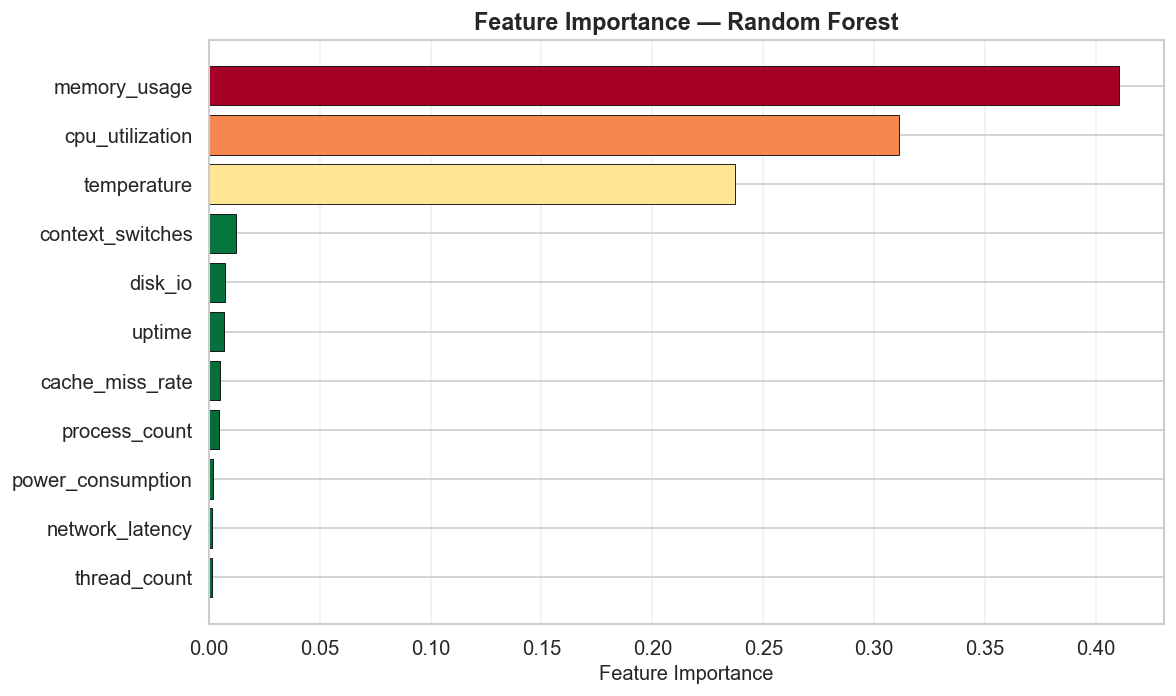

In [22]:
# ─── 6.4 Feature importance ──────────────────────────────────────────
# Get feature importance (works for tree-based models; use coefficients for linear)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    importance_label = 'Feature Importance'
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_[0])
    importance_label = 'Absolute Coefficient'
else:
    importances = None

if importances is not None:
    feat_imp = pd.DataFrame({
        'Feature': features,
        'Importance': importances
    }).sort_values('Importance', ascending=True)

    plt.figure(figsize=(10, 6))
    bars = plt.barh(feat_imp['Feature'], feat_imp['Importance'],
                    color=plt.cm.RdYlGn_r(feat_imp['Importance'] / feat_imp['Importance'].max()),
                    edgecolor='black', linewidth=0.5)
    plt.xlabel(importance_label, fontsize=12)
    plt.title(f'Feature Importance — {best_name}', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('results/08_feature_importance.png', bbox_inches='tight')
    plt.show()
else:
    print('Feature importance not available for this model type.')

In [23]:
# ─── 6.5 Summary statistics of bottleneck points ─────────────────────
print('═' * 60)
print('  BOTTLENECK vs WORKING — AVERAGE FEATURE VALUES')
print('═' * 60)

comparison = df.groupby('predicted_label')[features].mean().T
comparison['Difference'] = comparison['Bottleneck'] - comparison['Working']
comparison['% Higher'] = ((comparison['Bottleneck'] - comparison['Working']) / comparison['Working'] * 100).round(1)

print(comparison.to_string())
print()
print('\n✅ Pipeline complete! All results saved to the "results/" folder.')

════════════════════════════════════════════════════════════
  BOTTLENECK vs WORKING — AVERAGE FEATURE VALUES
════════════════════════════════════════════════════════════
predicted_label     Bottleneck      Working  Difference  % Higher
cpu_utilization      89.642019    51.579760   38.062258      73.8
memory_usage         92.431960    55.048811   37.383149      67.9
disk_io              23.976863    25.517257   -1.540394      -6.0
network_latency      94.579224   100.298872   -5.719648      -5.7
process_count       521.437500   517.195578    4.241922       0.8
thread_count       1840.510417  1811.047960   29.462456       1.6
context_switches   1113.385417  1038.140347   75.245069       7.2
cache_miss_rate       0.108149     0.105882    0.002267       2.1
temperature          84.654289    62.160784   22.493505      36.2
power_consumption   178.696511   174.748883    3.947628       2.3
uptime              533.408561   500.061230   33.347331       6.7


✅ Pipeline complete! All results sa